In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
def working_minutes(start,end,breaks):
    return (end-start).total_seconds()/60 - sum(breaks)

# Mazda
mazda_minutes = working_minutes(
    datetime(2026,1,1,7,14),
    datetime(2026,1,1,15,45),
    [10,45,12]
)

# Toyota
toyota_minutes = working_minutes(
    datetime(2026,1,1,7,8),
    datetime(2026,1,1,15,45),
    [10,45,12]
)

mazda_capacity = int((mazda_minutes*60)//78)
toyota_capacity = int((toyota_minutes*60)//75)

expected_daily_use = mazda_capacity + toyota_capacity

mazda_capacity, toyota_capacity, expected_daily_use

(341, 360, 701)

In [ ]:
DAYS = 240
np.random.seed(42)

INITIAL_INVENTORY_DAYS = 2.0
SUPPLIER_VARIABILITY = 0.05

In [ ]:
inventory = int(expected_daily_use *
                INITIAL_INVENTORY_DAYS)

records = []

for day in range(DAYS):

    # normal production variation
    mazda_output = int(
        mazda_capacity*np.random.normal(0.95,0.02)
    )

    toyota_output = int(
        toyota_capacity*np.random.normal(0.96,0.02)
    )

    consumption = mazda_output + toyota_output

    delivery = int(
        np.random.normal(
            expected_daily_use,
            expected_daily_use*SUPPLIER_VARIABILITY
        )
    )

    delivery = max(delivery,0)

    inventory = inventory + delivery - consumption
    inventory = max(inventory,0)

    records.append([
        day,
        consumption,
        delivery,
        inventory
    ])

In [ ]:
df = pd.DataFrame(records,
columns=[
    "Day",
    "Consumption",
    "Delivery",
    "Inventory"
])

df.head()

,Day,Consumption,Delivery,Inventory
0,0,671,723,1454
1,1,677,692,1469
2,2,685,684,1468
3,3,669,684,1483
4,4,656,640,1467


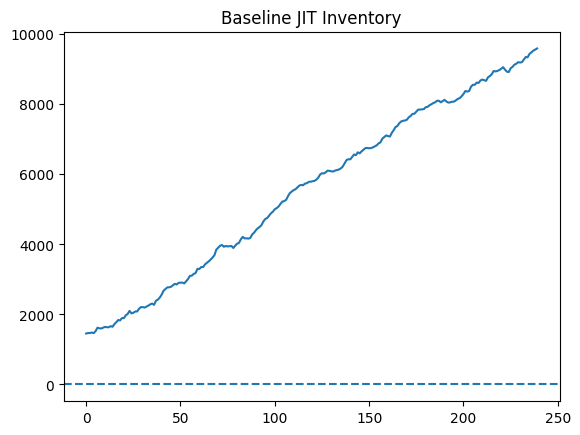

In [ ]:
plt.plot(df["Day"],df["Inventory"])
plt.title("Baseline JIT Inventory")
plt.axhline(0,linestyle="--")
plt.show()

In [ ]:
# Supplier disruption + recovery settings
SHOCK_PROBABILITY = 0.06   # ~6% chance a shock starts on any day
SHOCK_LENGTH = 5           # shock lasts 4 days
SHOCK_DELIVERY_FACTOR = 0.45  # deliveries drop to ~55% of normal in shock

RECOVERY_BONUS_FACTOR = 0.10  # extra deliveries when inventory is low (expedite)
RECOVERY_TRIGGER_DOS = 0.8    # trigger expedite if < 1.0 days-of-supply

In [ ]:
inventory = int(expected_daily_use * INITIAL_INVENTORY_DAYS)

records = []
shock_timer = 0

for day in range(DAYS):

    # --- production variation (same as baseline) ---
    mazda_output = int(mazda_capacity * np.random.normal(0.95, 0.02))
    toyota_output = int(toyota_capacity * np.random.normal(0.96, 0.02))
    consumption = max(mazda_output, 0) + max(toyota_output, 0)

    # --- shock trigger ---
    if shock_timer == 0 and np.random.rand() < SHOCK_PROBABILITY:
        shock_timer = SHOCK_LENGTH

    # --- delivery process ---
    if shock_timer > 0:
        # disrupted deliveries
        delivery = int(np.random.normal(
            expected_daily_use * SHOCK_DELIVERY_FACTOR,
            expected_daily_use * 0.05
        ))
        shock_timer -= 1
        shock_active = 1
    else:
        # normal deliveries
        delivery = int(np.random.normal(
            expected_daily_use,
            expected_daily_use * SUPPLIER_VARIABILITY
        ))
        shock_active = 0

    delivery = max(delivery, 0)

    # --- expedite recovery if inventory is low ---
    dos = inventory / max(expected_daily_use, 1)
    if dos < RECOVERY_TRIGGER_DOS:
        delivery += int(RECOVERY_BONUS_FACTOR * expected_daily_use)

    # --- update inventory ---
    inventory = inventory + delivery - consumption
    shortage = 1 if inventory <= 0 else 0
    inventory = max(inventory, 0)

    records.append([day, consumption, delivery, inventory, shortage, shock_active, dos])

In [ ]:
df = pd.DataFrame(records, columns=[
    "Day", "Consumption", "Delivery", "Inventory",
    "Shortage", "Shock", "Days_of_Supply"
])

df[["Shortage","Shock"]].sum()

,0
Shortage,43
Shock,70


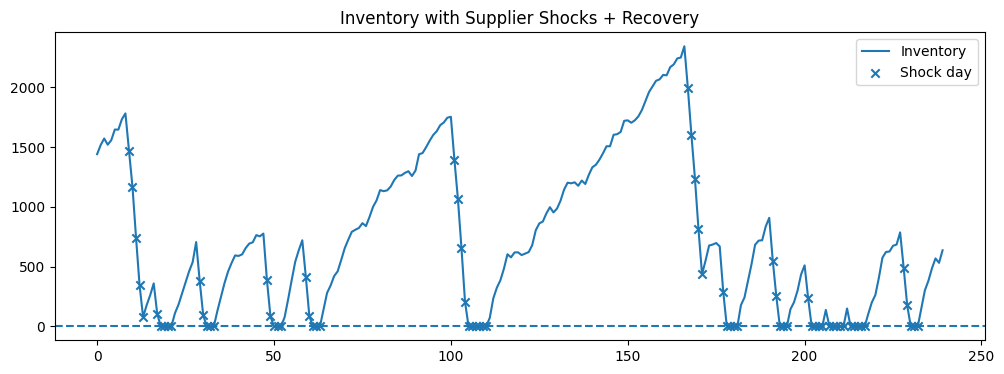

Total shortage days: 43


In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df["Day"], df["Inventory"], label="Inventory")

shock_days = df[df["Shock"]==1]["Day"]
plt.scatter(shock_days, df.loc[shock_days, "Inventory"], marker="x", label="Shock day")

plt.axhline(0, linestyle="--")
plt.title("Inventory with Supplier Shocks + Recovery")
plt.legend()
plt.show()

print("Total shortage days:", int(df["Shortage"].sum()))

In [ ]:
# ----- Overtime behavior -----

OT_DURATION = 2
OT_BOOST = 0.15

PRESSURE_THRESHOLD = 0.65

In [ ]:
inventory = int(expected_daily_use * INITIAL_INVENTORY_DAYS)

records = []

shock_timer = 0
ot_timer = 0

for day in range(DAYS):

    # -------------------------
    # perceived managerial pressure
    # -------------------------
    dos = inventory / max(expected_daily_use,1)

    perceived_pressure = (
        0.5*np.random.random() +
        0.5*(1 if dos < 1.0 else 0)
    )

    if ot_timer == 0 and perceived_pressure > PRESSURE_THRESHOLD:
        ot_timer = OT_DURATION

    OT_active = 1 if ot_timer > 0 else 0

    if ot_timer > 0:
        ot_timer -= 1

    # -------------------------
    # production
    # -------------------------
    boost = (1 + OT_BOOST) if OT_active else 1

    mazda_output = int(
        mazda_capacity *
        np.random.normal(0.95,0.02) *
        boost
    )

    toyota_output = int(
        toyota_capacity *
        np.random.normal(0.96,0.02) *
        boost
    )

    consumption = max(mazda_output,0) + max(toyota_output,0)

    # -------------------------
    # supplier shock logic
    # -------------------------
    if shock_timer == 0 and np.random.rand() < SHOCK_PROBABILITY:
        shock_timer = SHOCK_LENGTH

    if shock_timer > 0:
        delivery = int(np.random.normal(
            expected_daily_use*SHOCK_DELIVERY_FACTOR,
            expected_daily_use*0.05
        ))
        shock_timer -= 1
        shock_active = 1
    else:
        delivery = int(np.random.normal(
            expected_daily_use,
            expected_daily_use*SUPPLIER_VARIABILITY
        ))
        shock_active = 0

    delivery = max(delivery,0)

    # recovery expedite
    if dos < RECOVERY_TRIGGER_DOS:
        delivery += int(RECOVERY_BONUS_FACTOR*expected_daily_use)

    # -------------------------
    # inventory update
    # -------------------------
    inventory = inventory + delivery - consumption

    shortage = 1 if inventory <= 0 else 0
    inventory = max(inventory,0)

    records.append([
        day,
        inventory,
        consumption,
        delivery,
        shortage,
        shock_active,
        OT_active,
        dos
    ])

In [ ]:
df = pd.DataFrame(records,columns=[
    "Day",
    "Inventory",
    "Consumption",
    "Delivery",
    "Shortage",
    "Shock",
    "OT",
    "Days_of_Supply"
])

Shortage days: 80
Shock days: 73
OT days: 186


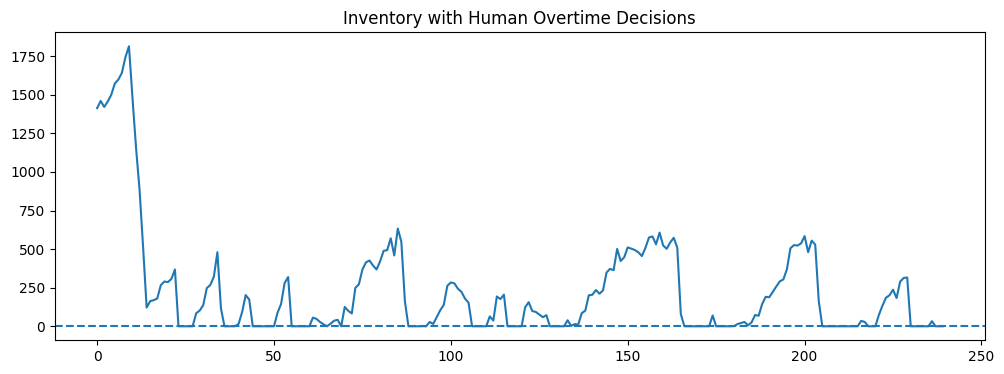

In [ ]:
print("Shortage days:", df["Shortage"].sum())
print("Shock days:", df["Shock"].sum())
print("OT days:", df["OT"].sum())

plt.figure(figsize=(12,4))
plt.plot(df["Day"], df["Inventory"])
plt.title("Inventory with Human Overtime Decisions")
plt.axhline(0,linestyle="--")
plt.show()

In [ ]:
HORIZON = 7

future_shortage = []

for i in range(len(df)):
    window = df["Shortage"].iloc[i+1:i+1+HORIZON]
    future_shortage.append(1 if window.sum() > 0 else 0)

df["Shortage_Next_7D"] = future_shortage

In [ ]:
df["Unnecessary_OT"] = (
    (df["OT"] == 1) &
    (df["Shortage_Next_7D"] == 0)
).astype(int)

print("Unnecessary OT Days:",
      df["Unnecessary_OT"].sum())

print("Percent Unnecessary:",
      round(
          100*df["Unnecessary_OT"].sum()
          / df["OT"].sum(),2
      ),"%")

Unnecessary OT Days: 60
Percent Unnecessary: 32.26 %


In [ ]:
df["Late_OT"] = (
    (df["OT"] == 1) &
    (df["Shortage"] == 1)
).astype(int)

print("Late OT Days:",
      df["Late_OT"].sum())

Late OT Days: 64


In [ ]:
df["Shortage_Tomorrow"] = df["Shortage"].shift(-1).fillna(0)

ot_days = df[df["OT"]==1]
non_ot_days = df[df["OT"]==0]

print(
"Next-day shortage rate WITH OT:",
round(ot_days["Shortage_Tomorrow"].mean(),3)
)

print(
"Next-day shortage rate WITHOUT OT:",
round(non_ot_days["Shortage_Tomorrow"].mean(),3)
)

Next-day shortage rate WITH OT: 0.355
Next-day shortage rate WITHOUT OT: 0.259


In [ ]:
HORIZON = 7

future_shortage = []

for i in range(len(df)):
    window = df["Shortage"].iloc[i+1:i+1+HORIZON]
    future_shortage.append(1 if window.sum() > 0 else 0)

df["Shortage_Next_7D"] = future_shortage

In [ ]:
df["Shortage_Next_7D"].value_counts(normalize=True)

,proportion
Shortage_Next_7D,
1,0.6375
0,0.3625


In [ ]:
df["Inv_7d_mean"] = df["Inventory"].rolling(7).mean()
df["Inv_7d_std"]  = df["Inventory"].rolling(7).std()

df["Cons_7d_mean"] = df["Consumption"].rolling(7).mean()
df["Del_7d_mean"]  = df["Delivery"].rolling(7).mean()

df["Shock_7d_sum"] = df["Shock"].rolling(7).sum()
df["OT_7d_sum"]    = df["OT"].rolling(7).sum()

df = df.dropna().reset_index(drop=True)

In [ ]:
features = [
    "Inventory",
    "Days_of_Supply",
    "Inv_7d_mean",
    "Inv_7d_std",
    "Cons_7d_mean",
    "Del_7d_mean",
    "Shock_7d_sum",
    "OT_7d_sum"
]

X = df[features]
y = df["Shortage_Next_7D"]

In [ ]:
split = int(len(df)*0.7)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

print("ROC-AUC:",
      round(roc_auc_score(y_test,proba),3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,pred))

print("\nClassification Report")
print(classification_report(y_test,pred))

ROC-AUC: 0.914

Confusion Matrix
[[18  5]
 [ 8 40]]

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.78      0.73        23
           1       0.89      0.83      0.86        48

    accuracy                           0.82        71
   macro avg       0.79      0.81      0.80        71
weighted avg       0.83      0.82      0.82        71



In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

,0
Del_7d_mean,0.216241
Inv_7d_mean,0.167848
Cons_7d_mean,0.141609
Inventory,0.121620
Inv_7d_std,0.117700
Days_of_Supply,0.105730
Shock_7d_sum,0.065357
OT_7d_sum,0.063896


In [ ]:
df["ML_Risk"] = model.predict_proba(X)[:,1]

In [ ]:
ML_THRESHOLD = 0.60

df["ML_OT"] = (
    df["ML_Risk"] > ML_THRESHOLD
).astype(int)

In [ ]:
print("Human OT Days:", df["OT"].sum())
print("ML OT Days:", df["ML_OT"].sum())

Human OT Days: 186
ML OT Days: 145


In [ ]:
df["ML_Unnecessary_OT"] = (
    (df["ML_OT"] == 1) &
    (df["Shortage_Next_7D"] == 0)
).astype(int)

print(
"ML Unnecessary OT %",
round(
100*df["ML_Unnecessary_OT"].sum()
/df["ML_OT"].sum(),2)
)

ML Unnecessary OT % 2.07


In [ ]:
comparison = pd.DataFrame({

"Policy":["Human","ML"],

"OT Days":[
df["OT"].sum(),
df["ML_OT"].sum()
],

"Unnecessary OT %":[
100*df["Unnecessary_OT"].mean(),
100*df["ML_Unnecessary_OT"].mean()
]

})

comparison

,Policy,OT Days,Unnecessary OT %
0,Human,186,25.641026
1,ML,145,1.282051


In [ ]:
import numpy as np
import pandas as pd

def _roll_stats(arr, window=7):
    """Return mean and std of last `window` values in arr. If not enough values, use what exists."""
    if len(arr) == 0:
        return 0.0, 0.0
    x = np.array(arr[-window:], dtype=float)
    mu = float(x.mean())
    sd = float(x.std(ddof=1)) if len(x) >= 2 else 0.0
    return mu, sd

def simulate_factory_closed_loop(
    policy,                  # "human" or "ml"
    model,
    features,
    DAYS,
    seed,
    # plant physics
    mazda_capacity,
    toyota_capacity,
    expected_daily_use,
    INITIAL_INVENTORY_DAYS,
    SUPPLIER_VARIABILITY,
    # shock + recovery
    SHOCK_PROBABILITY,
    SHOCK_LENGTH,
    SHOCK_DELIVERY_FACTOR,
    RECOVERY_BONUS_FACTOR,
    RECOVERY_TRIGGER_DOS,
    # overtime
    OT_DURATION,
    OT_BOOST,
    PRESSURE_THRESHOLD=0.65,
    ML_THRESHOLD=0.60
):
    rng = np.random.default_rng(seed)

    # Pre-generate all exogenous randomness so BOTH policies see the same world
    eff_maz = rng.normal(0.95, 0.02, size=DAYS)
    eff_toy = rng.normal(0.96, 0.02, size=DAYS)

    shock_start_u = rng.random(DAYS)              # shock start draws
    pressure_u = rng.random(DAYS)                 # perceived pressure noise

    deliv_norm = rng.normal(expected_daily_use, expected_daily_use*SUPPLIER_VARIABILITY, size=DAYS)
    deliv_shock = rng.normal(expected_daily_use*SHOCK_DELIVERY_FACTOR, expected_daily_use*0.05, size=DAYS)

    # State
    inventory = int(expected_daily_use * INITIAL_INVENTORY_DAYS)
    shock_timer = 0
    ot_timer = 0

    # History (for ML features)
    inv_hist = []
    cons_hist = []
    del_hist = []
    shock_hist = []
    ot_hist = []

    records = []

    for day in range(DAYS):
        # Start-of-day Days of Supply
        dos = inventory / max(expected_daily_use, 1)

        # -------------------------
        # Decide OT (control)
        # -------------------------
        if policy == "human":
            perceived_pressure = 0.5*pressure_u[day] + 0.5*(1 if dos < 1.0 else 0)
            if ot_timer == 0 and perceived_pressure > PRESSURE_THRESHOLD:
                ot_timer = OT_DURATION

        elif policy == "ml":
            # Build "past-only" features (use last 7 days ENDING YESTERDAY)
            inv_mu, inv_sd = _roll_stats(inv_hist, 7)
            cons_mu, _ = _roll_stats(cons_hist, 7)
            del_mu, _ = _roll_stats(del_hist, 7)

            shock_7 = int(np.sum(shock_hist[-7:])) if len(shock_hist) > 0 else 0
            ot_7 = int(np.sum(ot_hist[-7:])) if len(ot_hist) > 0 else 0

            x_row = pd.DataFrame([{
                "Inventory": float(inventory),
                "Days_of_Supply": float(dos),
                "Inv_7d_mean": float(inv_mu),
                "Inv_7d_std": float(inv_sd),
                "Cons_7d_mean": float(cons_mu),
                "Del_7d_mean": float(del_mu),
                "Shock_7d_sum": float(shock_7),
                "OT_7d_sum": float(ot_7),
            }])[features]

            risk = float(model.predict_proba(x_row)[0, 1])

            if ot_timer == 0 and risk > ML_THRESHOLD:
                ot_timer = OT_DURATION

        else:
            raise ValueError("policy must be 'human' or 'ml'")

        OT_active = 1 if ot_timer > 0 else 0
        if ot_timer > 0:
            ot_timer -= 1

        # -------------------------
        # Production (consumption)
        # -------------------------
        boost = (1 + OT_BOOST) if OT_active else 1.0

        mazda_output = int(max(0, mazda_capacity * eff_maz[day] * boost))
        toyota_output = int(max(0, toyota_capacity * eff_toy[day] * boost))
        consumption = mazda_output + toyota_output

        # -------------------------
        # Supplier shock
        # -------------------------
        if shock_timer == 0 and shock_start_u[day] < SHOCK_PROBABILITY:
            shock_timer = SHOCK_LENGTH

        if shock_timer > 0:
            delivery = int(max(0, deliv_shock[day]))
            shock_timer -= 1
            shock_active = 1
        else:
            delivery = int(max(0, deliv_norm[day]))
            shock_active = 0

        # Expedite recovery if low inventory
        if dos < RECOVERY_TRIGGER_DOS:
            delivery += int(RECOVERY_BONUS_FACTOR * expected_daily_use)

        # -------------------------
        # Inventory update
        # -------------------------
        inventory = inventory + delivery - consumption
        shortage = 1 if inventory <= 0 else 0
        inventory = max(inventory, 0)

        # Save history for next day's ML features
        inv_hist.append(inventory)
        cons_hist.append(consumption)
        del_hist.append(delivery)
        shock_hist.append(shock_active)
        ot_hist.append(OT_active)

        records.append([day, inventory, consumption, delivery, shortage, shock_active, OT_active, dos])

    df_sim = pd.DataFrame(records, columns=[
        "Day","Inventory","Consumption","Delivery","Shortage","Shock","OT","Days_of_Supply"
    ])
    return df_sim

def add_kpis(df, horizon=7):
    df = df.copy()

    # Shortage in next H days
    future = []
    for i in range(len(df)):
        window = df["Shortage"].iloc[i+1:i+1+horizon]
        future.append(1 if window.sum() > 0 else 0)
    df["Shortage_Next_7D"] = future

    df["Unnecessary_OT"] = ((df["OT"]==1) & (df["Shortage_Next_7D"]==0)).astype(int)
    df["Late_OT"] = ((df["OT"]==1) & (df["Shortage"]==1)).astype(int)

    df["Shortage_Tomorrow"] = df["Shortage"].shift(-1).fillna(0).astype(int)

    # Summary metrics
    ot_days = int(df["OT"].sum())
    shortages = int(df["Shortage"].sum())
    unnec = int(df["Unnecessary_OT"].sum())
    late = int(df["Late_OT"].sum())

    with_ot = df[df["OT"]==1]["Shortage_Tomorrow"].mean() if ot_days > 0 else 0.0
    without_ot = df[df["OT"]==0]["Shortage_Tomorrow"].mean() if ot_days < len(df) else 0.0

    summary = {
        "OT Days": ot_days,
        "Shortage Days": shortages,
        "Unnecessary OT Days": unnec,
        "Unnecessary OT %": (100*unnec/ot_days) if ot_days>0 else 0.0,
        "Late OT Days": late,
        "Next-day shortage WITH OT": float(with_ot),
        "Next-day shortage WITHOUT OT": float(without_ot),
    }
    return df, summary

In [ ]:
# Use your existing parameter values from Stage 2/3
# (These names assume you already defined them earlier)
# DAYS, mazda_capacity, toyota_capacity, expected_daily_use, etc.

df_human = simulate_factory_closed_loop(
    policy="human",
    model=model,
    features=features,
    DAYS=DAYS,
    seed=123,  # any fixed seed is fine; same seed used for both
    mazda_capacity=mazda_capacity,
    toyota_capacity=toyota_capacity,
    expected_daily_use=expected_daily_use,
    INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
    SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
    SHOCK_PROBABILITY=SHOCK_PROBABILITY,
    SHOCK_LENGTH=SHOCK_LENGTH,
    SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
    RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
    RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
    OT_DURATION=OT_DURATION,
    OT_BOOST=OT_BOOST,
    PRESSURE_THRESHOLD=PRESSURE_THRESHOLD,
    ML_THRESHOLD=0.60
)

df_ml = simulate_factory_closed_loop(
    policy="ml",
    model=model,
    features=features,
    DAYS=DAYS,
    seed=123,  # SAME seed → SAME shocks/efficiencies/delivery noise
    mazda_capacity=mazda_capacity,
    toyota_capacity=toyota_capacity,
    expected_daily_use=expected_daily_use,
    INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
    SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
    SHOCK_PROBABILITY=SHOCK_PROBABILITY,
    SHOCK_LENGTH=SHOCK_LENGTH,
    SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
    RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
    RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
    OT_DURATION=OT_DURATION,
    OT_BOOST=OT_BOOST,
    PRESSURE_THRESHOLD=PRESSURE_THRESHOLD,
    ML_THRESHOLD=0.60
)

df_human_kpi, s_human = add_kpis(df_human, horizon=7)
df_ml_kpi, s_ml = add_kpis(df_ml, horizon=7)

pd.DataFrame([s_human, s_ml], index=["Human Policy", "ML Policy"])

,OT Days,Shortage Days,Unnecessary OT Days,Unnecessary OT %,Late OT Days,Next-day shortage WITH OT,Next-day shortage WITHOUT OT
Human Policy,179,37,119,66.480447,31,0.173184,0.098361
ML Policy,0,20,0,0.000000,0,0.000000,0.083333


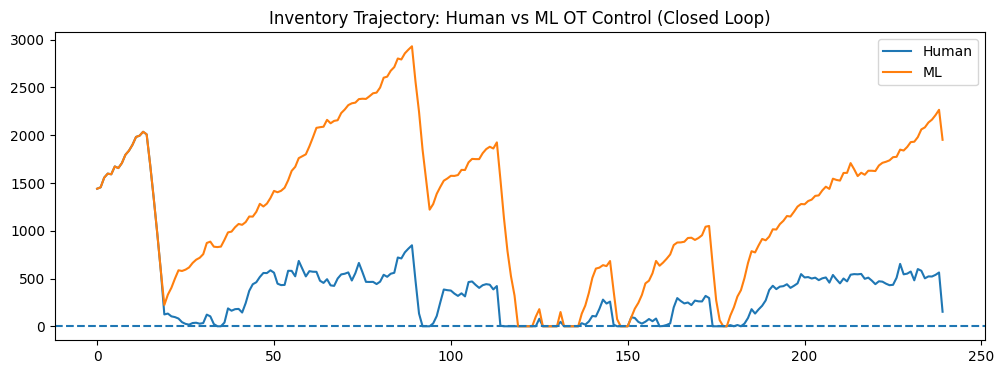

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df_human_kpi["Day"], df_human_kpi["Inventory"], label="Human")
plt.plot(df_ml_kpi["Day"], df_ml_kpi["Inventory"], label="ML")
plt.axhline(0, linestyle="--")
plt.title("Inventory Trajectory: Human vs ML OT Control (Closed Loop)")
plt.legend()
plt.show()

In [ ]:
def pct_change(new, old):
    return 100*(new-old)/old if old != 0 else np.nan

headline = {
    "OT Days Δ% (ML vs Human)": pct_change(s_ml["OT Days"], s_human["OT Days"]),
    "Shortage Days Δ% (ML vs Human)": pct_change(s_ml["Shortage Days"], s_human["Shortage Days"]),
    "Unnecessary OT % (Human)": s_human["Unnecessary OT %"],
    "Unnecessary OT % (ML)": s_ml["Unnecessary OT %"],
}
pd.Series(headline)

,0
OT Days Δ% (ML vs Human),-100.000000
Shortage Days Δ% (ML vs Human),-45.945946
Unnecessary OT % (Human),66.480447
Unnecessary OT % (ML),0.000000


In [ ]:
results = []

for thresh in np.arange(0.30,0.71,0.05):

    df_ml = simulate_factory_closed_loop(
        policy="ml",
        model=model,
        features=features,
        DAYS=DAYS,
        seed=123,
        mazda_capacity=mazda_capacity,
        toyota_capacity=toyota_capacity,
        expected_daily_use=expected_daily_use,
        INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
        SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
        SHOCK_PROBABILITY=SHOCK_PROBABILITY,
        SHOCK_LENGTH=SHOCK_LENGTH,
        SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
        RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
        RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
        OT_DURATION=OT_DURATION,
        OT_BOOST=OT_BOOST,
        ML_THRESHOLD=thresh
    )

    _, summary = add_kpis(df_ml)

    summary["Threshold"] = thresh
    results.append(summary)

pd.DataFrame(results)

,OT Days,Shortage Days,Unnecessary OT Days,Unnecessary OT %,Late OT Days,Next-day shortage WITH OT,Next-day shortage WITHOUT OT,Threshold
0,222,54,135,60.810811,54,0.243243,0.000000,0.30
1,218,54,133,61.009174,54,0.247706,0.000000,0.35
2,192,43,126,65.625000,43,0.223958,0.000000,0.40
3,102,32,62,60.784314,27,0.254902,0.043478,0.45
4,98,32,60,61.224490,24,0.234694,0.063380,0.50
5,0,20,0,0.000000,0,0.000000,0.083333,0.55
6,0,20,0,0.000000,0,0.000000,0.083333,0.60
7,0,20,0,0.000000,0,0.000000,0.083333,0.65
8,0,20,0,0.000000,0,0.000000,0.083333,0.70


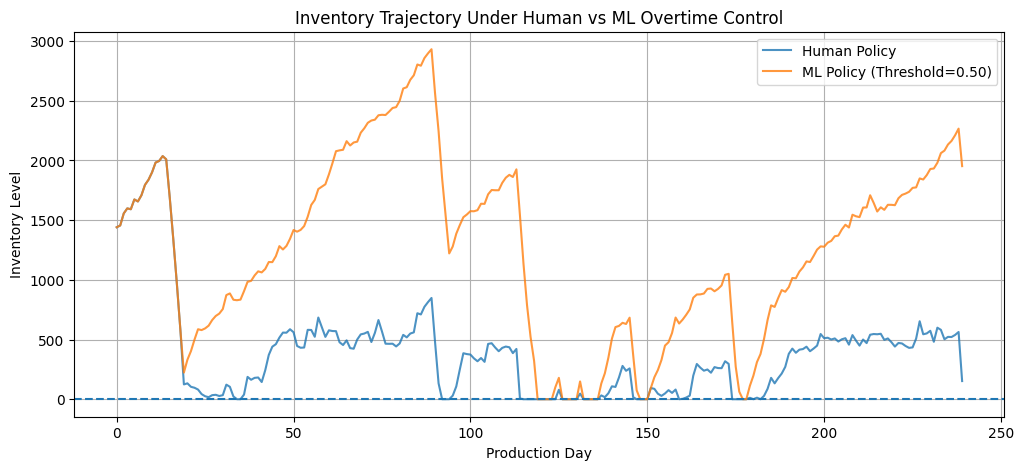

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df_human_kpi["Day"],
    df_human_kpi["Inventory"],
    label="Human Policy",
    alpha=0.8
)

plt.plot(
    df_ml_kpi["Day"],
    df_ml_kpi["Inventory"],
    label="ML Policy (Threshold=0.50)",
    alpha=0.8
)

plt.axhline(0, linestyle="--")

plt.title("Inventory Trajectory Under Human vs ML Overtime Control")
plt.xlabel("Production Day")
plt.ylabel("Inventory Level")

plt.legend()
plt.grid(True)

plt.show()

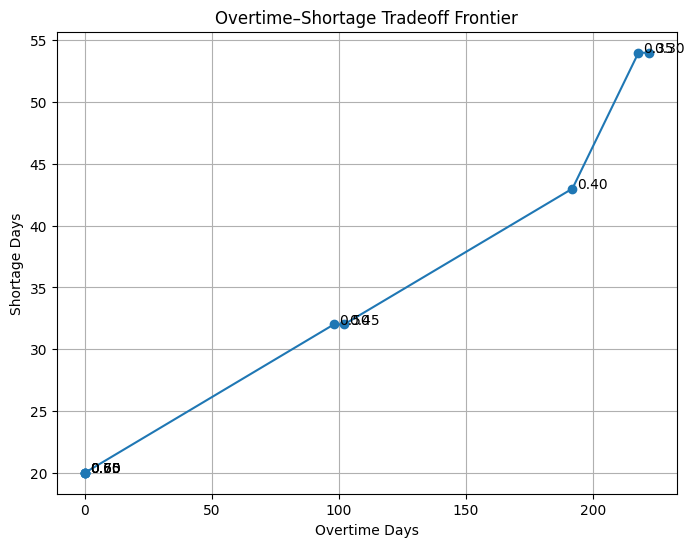

In [ ]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(8,6))

plt.plot(
    results_df["OT Days"],
    results_df["Shortage Days"],
    marker="o"
)

for i,row in results_df.iterrows():
    plt.text(
        row["OT Days"]+2,
        row["Shortage Days"],
        f'{row["Threshold"]:.2f}'
    )

plt.title("Overtime–Shortage Tradeoff Frontier")
plt.xlabel("Overtime Days")
plt.ylabel("Shortage Days")

plt.grid(True)
plt.show()

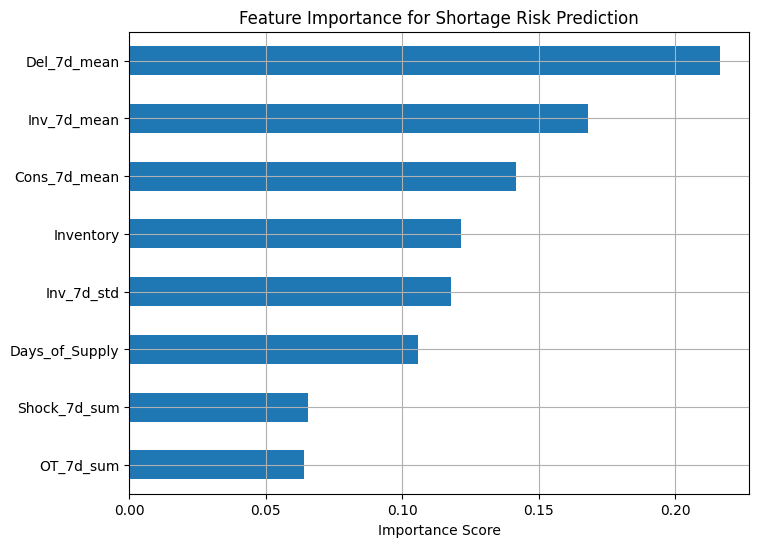

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,6))

importance.plot(kind="barh")

plt.title("Feature Importance for Shortage Risk Prediction")
plt.xlabel("Importance Score")

plt.grid(True)
plt.show()

In [167]:
N_RUNS = 5

results_mc = []

for seed in range(N_RUNS):

    # Human system
    df_h = simulate_factory_closed_loop(
        policy="human",
        model=model,
        features=features,
        DAYS=DAYS,
        seed=seed,
        mazda_capacity=mazda_capacity,
        toyota_capacity=toyota_capacity,
        expected_daily_use=expected_daily_use,
        INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
        SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
        SHOCK_PROBABILITY=SHOCK_PROBABILITY,
        SHOCK_LENGTH=SHOCK_LENGTH,
        SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
        RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
        RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
        OT_DURATION=OT_DURATION,
        OT_BOOST=OT_BOOST
    )

    _, human_summary = add_kpis(df_h)

    # ML system
    df_ml = simulate_factory_closed_loop(
        policy="ml",
        model=model,
        features=features,
        DAYS=DAYS,
        seed=seed,
        mazda_capacity=mazda_capacity,
        toyota_capacity=toyota_capacity,
        expected_daily_use=expected_daily_use,
        INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
        SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
        SHOCK_PROBABILITY=SHOCK_PROBABILITY,
        SHOCK_LENGTH=SHOCK_LENGTH,
        SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
        RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
        RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
        OT_DURATION=OT_DURATION,
        OT_BOOST=OT_BOOST,
        ML_THRESHOLD=0.50
    )

    _, ml_summary = add_kpis(df_ml)

    results_mc.append({
        "seed": seed,
        "Human_OT": human_summary["OT Days"],
        "ML_OT": ml_summary["OT Days"],
        "Human_Shortages": human_summary["Shortage Days"],
        "ML_Shortages": ml_summary["Shortage Days"]
    })

results_mc = pd.DataFrame(results_mc)
results_mc.head()

,seed,Human_OT,ML_OT,Human_Shortages,ML_Shortages
0,0,180,173,53,44
1,1,198,86,39,21
2,2,182,145,31,30
3,3,192,157,66,61
4,4,174,155,57,55


In [168]:
N_RUNS = 50

results_mc = []

for seed in range(N_RUNS):

    # Human system
    df_h = simulate_factory_closed_loop(
        policy="human",
        model=model,
        features=features,
        DAYS=DAYS,
        seed=seed,
        mazda_capacity=mazda_capacity,
        toyota_capacity=toyota_capacity,
        expected_daily_use=expected_daily_use,
        INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
        SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
        SHOCK_PROBABILITY=SHOCK_PROBABILITY,
        SHOCK_LENGTH=SHOCK_LENGTH,
        SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
        RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
        RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
        OT_DURATION=OT_DURATION,
        OT_BOOST=OT_BOOST
    )

    _, human_summary = add_kpis(df_h)

    # ML system
    df_ml = simulate_factory_closed_loop(
        policy="ml",
        model=model,
        features=features,
        DAYS=DAYS,
        seed=seed,
        mazda_capacity=mazda_capacity,
        toyota_capacity=toyota_capacity,
        expected_daily_use=expected_daily_use,
        INITIAL_INVENTORY_DAYS=INITIAL_INVENTORY_DAYS,
        SUPPLIER_VARIABILITY=SUPPLIER_VARIABILITY,
        SHOCK_PROBABILITY=SHOCK_PROBABILITY,
        SHOCK_LENGTH=SHOCK_LENGTH,
        SHOCK_DELIVERY_FACTOR=SHOCK_DELIVERY_FACTOR,
        RECOVERY_BONUS_FACTOR=RECOVERY_BONUS_FACTOR,
        RECOVERY_TRIGGER_DOS=RECOVERY_TRIGGER_DOS,
        OT_DURATION=OT_DURATION,
        OT_BOOST=OT_BOOST,
        ML_THRESHOLD=0.50
    )

    _, ml_summary = add_kpis(df_ml)

    results_mc.append({
        "seed": seed,
        "Human_OT": human_summary["OT Days"],
        "ML_OT": ml_summary["OT Days"],
        "Human_Shortages": human_summary["Shortage Days"],
        "ML_Shortages": ml_summary["Shortage Days"]
    })

results_mc = pd.DataFrame(results_mc)
results_mc.head()

,seed,Human_OT,ML_OT,Human_Shortages,ML_Shortages
0,0,180,173,53,44
1,1,198,86,39,21
2,2,182,145,31,30
3,3,192,157,66,61
4,4,174,155,57,55


In [169]:
results_mc.mean()

,0
seed,24.50
Human_OT,179.92
ML_OT,135.24
Human_Shortages,64.04
ML_Shortages,54.08


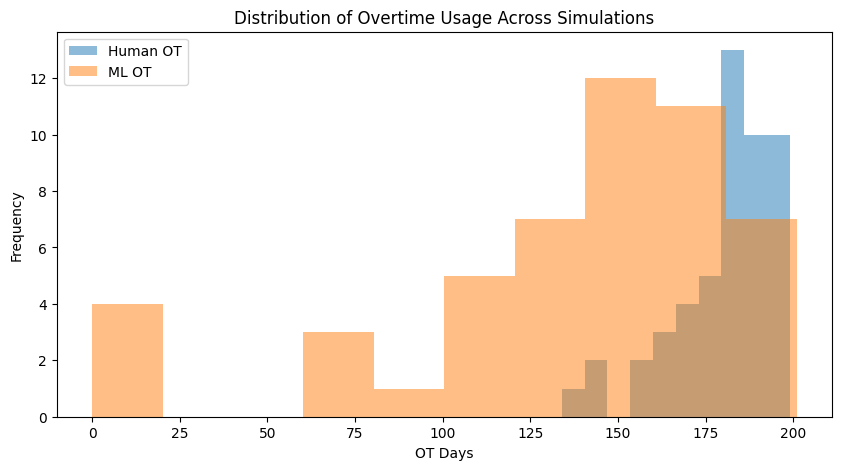

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(results_mc["Human_OT"],
         alpha=0.5,
         label="Human OT")

plt.hist(results_mc["ML_OT"],
         alpha=0.5,
         label="ML OT")

plt.legend()
plt.title("Distribution of Overtime Usage Across Simulations")
plt.xlabel("OT Days")
plt.ylabel("Frequency")

plt.show()

In [171]:
from scipy.stats import ttest_rel

ttest_rel(
    results_mc["Human_OT"],
    results_mc["ML_OT"]
)

TtestResult(statistic=np.float64(5.93548615944555), pvalue=np.float64(2.941823250524573e-07), df=np.int64(49))

In [172]:
results_mc.to_csv("monte_carlo_results.csv", index=False)

In [173]:
from google.colab import files
files.download("monte_carlo_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [174]:
results_mc["Shortage_Improvement"] = (
    results_mc["Human_Shortages"]
    - results_mc["ML_Shortages"]
)

results_mc.head()

,seed,Human_OT,ML_OT,Human_Shortages,ML_Shortages,Shortage_Improvement
0,0,180,173,53,44,9
1,1,198,86,39,21,18
2,2,182,145,31,30,1
3,3,192,157,66,61,5
4,4,174,155,57,55,2


In [175]:
prob_improve = (
    results_mc["Shortage_Improvement"] > 0
).mean()

print(
"Probability ML reduces shortages:",
round(prob_improve,3)
)

Probability ML reduces shortages: 0.86


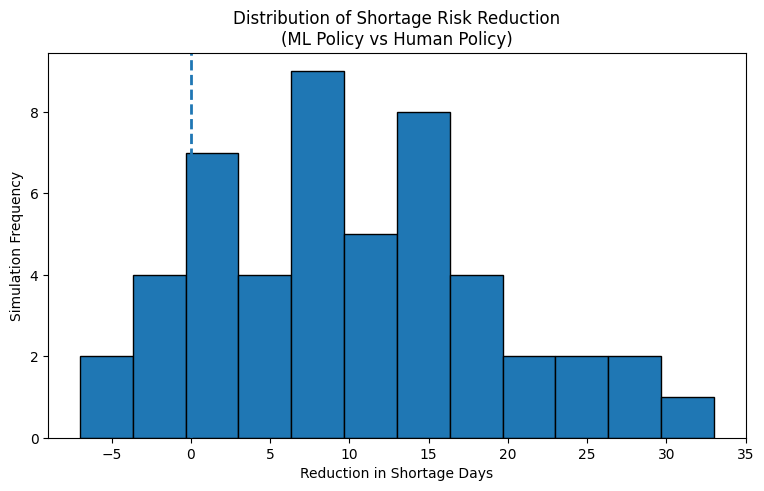

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.hist(
    results_mc["Shortage_Improvement"],
    bins=12,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Distribution of Shortage Risk Reduction\n(ML Policy vs Human Policy)")
plt.xlabel("Reduction in Shortage Days")
plt.ylabel("Simulation Frequency")

plt.show()